### 1- Importation et chargement

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Config display
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

# Chargement des datasets
df_sirh = pd.read_csv('public/extrait_sirh.csv')
df_eval = pd.read_csv('public/extrait_eval.csv')
df_sondage = pd.read_csv('public/extrait_sondage.csv')

print(f"Chargement terminé : SIRH {df_sirh.shape}, Eval {df_eval.shape}, Sondage {df_sondage.shape}")

Chargement terminé : SIRH (1470, 12), Eval (1470, 10), Sondage (1470, 12)


### 2- Stats Descriptives

In [32]:
# Analyse rapide des fichiers bruts
datasets = {"SIRH": df_sirh, "Eval": df_eval, "Sondage": df_sondage}

for name, df in datasets.items():
    print(f"\n--- Statistiques descriptives : {name} ---")
    # Aperçu des stats pour les colonnes numériques
    print(df.describe())
    # Aperçu pour vérifier les types et les valeurs manquantes
    print(f"\nInfos structurelles {name} :")
    print(df.info())


--- Statistiques descriptives : SIRH ---
       id_employee          age  revenu_mensuel  \
count  1470.000000  1470.000000     1470.000000   
mean   1024.865306    36.923810     6502.931293   
std     602.024335     9.135373     4707.956783   
min       1.000000    18.000000     1009.000000   
25%     491.250000    30.000000     2911.000000   
50%    1020.500000    36.000000     4919.000000   
75%    1555.750000    43.000000     8379.000000   
max    2068.000000    60.000000    19999.000000   

       nombre_experiences_precedentes  nombre_heures_travailless  \
count                     1470.000000                     1470.0   
mean                         2.693197                       80.0   
std                          2.498009                        0.0   
min                          0.000000                       80.0   
25%                          1.000000                       80.0   
50%                          2.000000                       80.0   
75%                   

### 3- Nettoyage des données

In [33]:
# 1. Nettoyage Fichier Eval
# Extraction de l'ID numérique depuis 'E_1'
df_eval['id_employee'] = df_eval['eval_number'].apply(lambda x: int(x.split('_')[1]))

# Conversion du pourcentage string '11 %' vers float 0.11
def clean_percent(val):
    if isinstance(val, str):
        return float(val.replace('%', '').strip()) / 100
    return val

df_eval['augementation_salaire_precedente'] = df_eval['augementation_salaire_precedente'].apply(clean_percent)

# 2. Nettoyage Fichier Sondage
# Renommage pour uniformiser la clé de jointure
df_sondage = df_sondage.rename(columns={'code_sondage': 'id_employee'})

# Création de la Target binaire (1 = Départ, 0 = Reste)
df_sondage['target'] = df_sondage['a_quitte_l_entreprise'].apply(lambda x: 1 if x == 'Oui' else 0)

# nombre_employee_sous_responsabilite
df_sondage = df_sondage.drop(columns=['nombre_employee_sous_responsabilite'])

# 3. Nettoyage Fichier SIRH
#Supprimer les colonnes constantes 
df_sirh = df_sirh.drop(columns=['nombre_heures_travailless'])

print("Nettoyage des colonnes effectué.")

Nettoyage des colonnes effectué.


### 4- Jointure des fichiers

In [34]:
# Fusion des dataframes
# On merge d'abord SIRH et Eval, puis le résultat avec Sondage
df_merged = df_sirh.merge(df_eval, on='id_employee', how='inner') \
                   .merge(df_sondage, on='id_employee', how='inner')

# Vérification des dimensions
print(f"Dimensions du DataFrame final : {df_merged.shape}")

# Vérification d'unicité (s'assurer qu'on a pas créé de doublons)
if df_merged['id_employee'].duplicated().sum() == 0:
    print("Intégrité de la jointure : OK (aucun doublon d'employé)")
else:
    print("Attention : Doublons détectés après jointure")

Dimensions du DataFrame final : (1470, 32)
Intégrité de la jointure : OK (aucun doublon d'employé)


### 5- Statistiques descriptives

In [35]:
# Sélection des variables clés à analyser
cols_to_analyze = [
    'age', 
    'revenu_mensuel', 
    'distance_domicile_travail', 
    'satisfaction_employee_environnement', 
    'augementation_salaire_precedente' # format float nettoyé précédemment
]

# Calcul des moyennes par groupe (0 vs 1)
stats_diff = df_merged.groupby('target')[cols_to_analyze].mean().reset_index()

print("Comparaison des profils (0 = Reste, 1 = Démissionne) :")
print(stats_diff)

Comparaison des profils (0 = Reste, 1 = Démissionne) :
   target        age  revenu_mensuel  distance_domicile_travail  \
0       0  37.561233     6832.739659                   8.915653   
1       1  33.607595     4787.092827                  10.632911   

   satisfaction_employee_environnement  augementation_salaire_precedente  
0                             2.771290                          0.152311  
1                             2.464135                          0.150970  


### 6- Visualisation

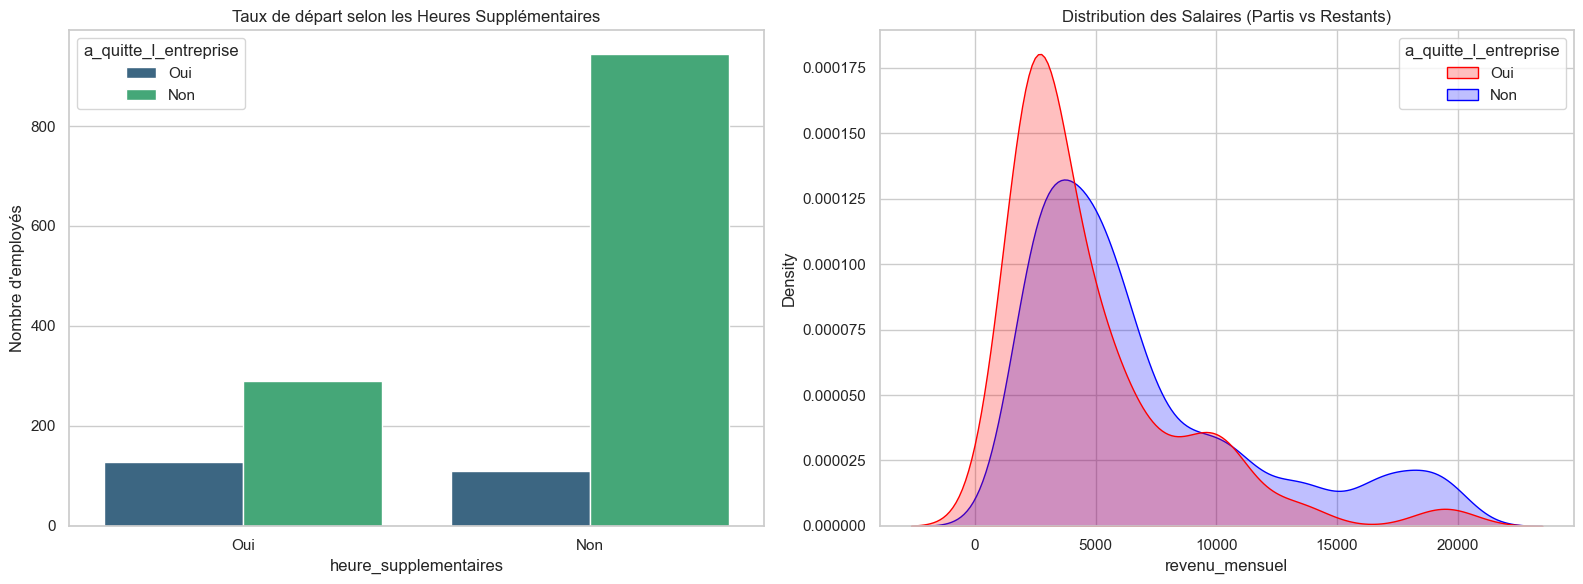

In [ ]:
# Configuration de la zone de dessin (2 graphiques côte à côte)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. Impact des Heures Supplémentaires (Variable Catégorielle)
sns.countplot(
    data=df_merged, 
    x='heure_supplementaires', 
    hue='a_quitte_l_entreprise', 
    palette='viridis', 
    ax=ax[0]
)
ax[0].set_title("Taux de départ selon les Heures Supplémentaires")
ax[0].set_ylabel("Nombre d'employés")

# 2. Distribution des Revenus (Variable Continue)
sns.kdeplot(
    data=df_merged, 
    x='revenu_mensuel', 
    hue='a_quitte_l_entreprise', 
    fill=True,
    palette=['red', 'blue'], 
    common_norm=False, 
    ax=ax[1]
)
ax[1].set_title("Distribution des Salaires (Partis vs Restants)")

plt.tight_layout()
plt.show()

### 7- Génération du fichier csv joint

In [37]:
# Sauvegarde du fichier propre
output_file = "dataset_technova_clean.csv"
df_merged.to_csv(output_file, index=False)

print(f"Fichier '{output_file}' généré avec succès. Prêt pour la modélisation.")

Fichier 'dataset_technova_clean.csv' généré avec succès. Prêt pour la modélisation.
